In [111]:
from matplotlib import pyplot as plt

from eitprocessing.datahandling.continuousdata import ContinuousData
from eitprocessing.datahandling.loading import load_eit_data
from eitprocessing.filters.butterworth_filters import LowPassFilter
from eitprocessing.parameters.eeli import EELI

MINUTE = 60

Load a sequence from file.


In [112]:
sequence = load_eit_data(
    "/home/mahyart/Desktop/github_repos/EIT/eitprocessing/test_data/draeger_synthetic_draeger_20Hz.bin",
    vendor="draeger",
)
sequence_no_cardiac = load_eit_data(
    "/home/mahyart/Desktop/github_repos/EIT/eitprocessing/test_data/draeger_synthetic_draeger_20Hz_no_cardiac.bin",
    vendor="draeger",
)
sequence_base = load_eit_data(
    "/home/mahyart/Desktop/github_repos/EIT/eitprocessing/test_data/draeger_synthetic_draeger_20Hz_base.bin",
    vendor="draeger",
)


Filter the global impedance using a low pass filter.


In [113]:
def add_lowpass_global_impedance(sequence):
    gi = sequence.continuous_data["global_impedance_(raw)"]

    filter_params = {
        "sample_frequency": sequence.eit_data["raw"].sample_frequency,
        "cutoff_frequency": 50 / MINUTE,
        "order": 10,
    }
    filter_ = LowPassFilter(**filter_params)

    sequence.continuous_data.add(
        ContinuousData(
            "global_impedance_(lowpass)",
            "Global impedance (low pass filtered)",
            "a.u.",
            "impedance",
            derived_from=[*gi.derived_from, gi],
            parameters={LowPassFilter: filter_params},
            time=gi.time,
            values=filter_.apply_filter(gi.values),
            sample_frequency=gi.sample_frequency,
        ),
        overwrite=True,
    )


add_lowpass_global_impedance(sequence)
add_lowpass_global_impedance(sequence_no_cardiac)


/tmp/ipykernel_311491/3477884257.py:20: DeprecationWarning: The `apply_filter` method is deprecated. Use `apply` instead.
  values=filter_.apply_filter(gi.values),


Select a small portion of the sequence.


In [114]:
# sequence = sequence.t[56600:56650]

Determine the EELI of the selected portion.


In [115]:
dataset_sequences = {
    "draeger": {
        "dataset_label": "Draeger synthetic",
        "sequence": sequence,
    },
    "draeger_no_cardiac": {
        "dataset_label": "Draeger synthetic (no cardiac)",
        "sequence": sequence_no_cardiac,
    },
}

dataset_results = {}
for dataset_key, dataset_info in dataset_sequences.items():
    dataset_sequence = dataset_info["sequence"]
    raw_signal = dataset_sequence.continuous_data["global_impedance_(raw)"]
    lowpass_signal = dataset_sequence.continuous_data["global_impedance_(lowpass)"]
    dataset_results[dataset_key] = {
        "dataset_label": dataset_info["dataset_label"],
        "sequence": dataset_sequence,
        "raw_signal": raw_signal,
        "lowpass_signal": lowpass_signal,
        "eeli_raw": EELI().compute_parameter(raw_signal),
        "eeli_lowpass": EELI().compute_parameter(lowpass_signal),
    }

raw_signal_data = dataset_results["draeger"]["raw_signal"]
filtered_signal_data = dataset_results["draeger"]["lowpass_signal"]
raw_signal_data_no_cardiac = dataset_results["draeger_no_cardiac"]["raw_signal"]
filtered_signal_data_no_cardiac = dataset_results["draeger_no_cardiac"]["lowpass_signal"]
raw_signal_data_base = sequence_base.continuous_data["global_impedance_(raw)"]
base_dataset_label = "base"


Plot the results.

Note that the variation in the EELI has decreased after filtering the global impedance. The filter removed the high
frequency noise (mainly cardiac artifacts), which was causing the EELI to fluctuate.


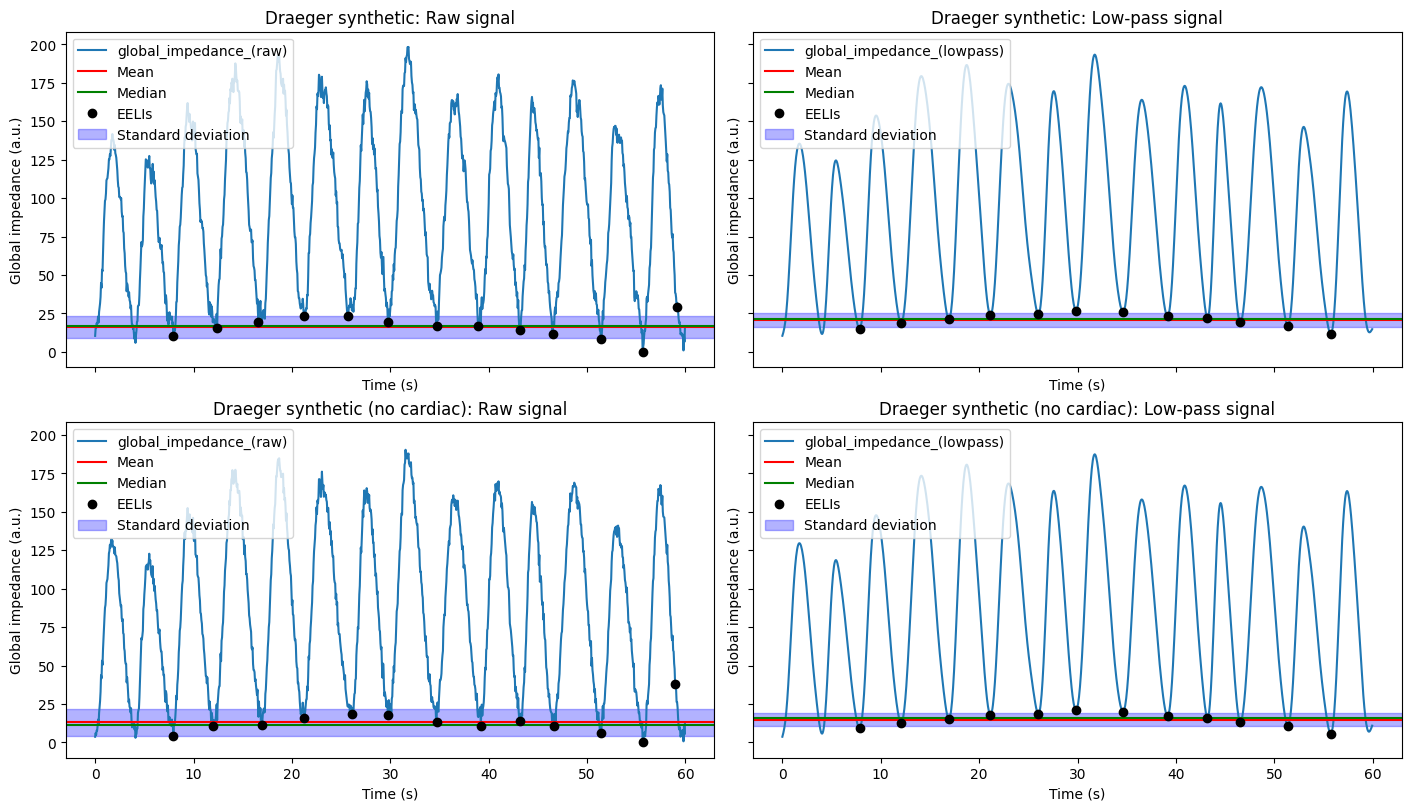

In [116]:
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True, constrained_layout=True)
plot_columns = [
    ("eeli_raw", "raw_signal", "Raw signal"),
    ("eeli_lowpass", "lowpass_signal", "Low-pass signal"),
]

for row, dataset_key in enumerate(dataset_results):
    dataset_info = dataset_results[dataset_key]
    for col, (result_key, signal_key, plot_label) in enumerate(plot_columns):
        ax = axes[row, col]
        result = dataset_info[result_key]
        gi = dataset_info[signal_key]
        result_values = np.asarray(result.values)
        sd_upper = np.mean(result_values) + np.std(result_values)
        sd_lower = np.mean(result_values) - np.std(result_values)

        ax.plot(gi.time, gi.values, label=gi.label)
        ax.axhline(np.mean(result_values), color="red", label="Mean")
        ax.axhline(np.median(result_values), color="green", label="Median")
        ax.plot(
            result.time,
            result,
            "o",
            color="black",
            label="EELIs",
        )

        xlim = ax.get_xlim()
        ax.fill_between(
            xlim,
            sd_upper,
            sd_lower,
            color="blue",
            alpha=0.3,
            label="Standard deviation",
        )
        ax.set_xlim(xlim)
        ax.set_title(f"{dataset_info['dataset_label']}: {plot_label}")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Global impedance (a.u.)")
        ax.legend()


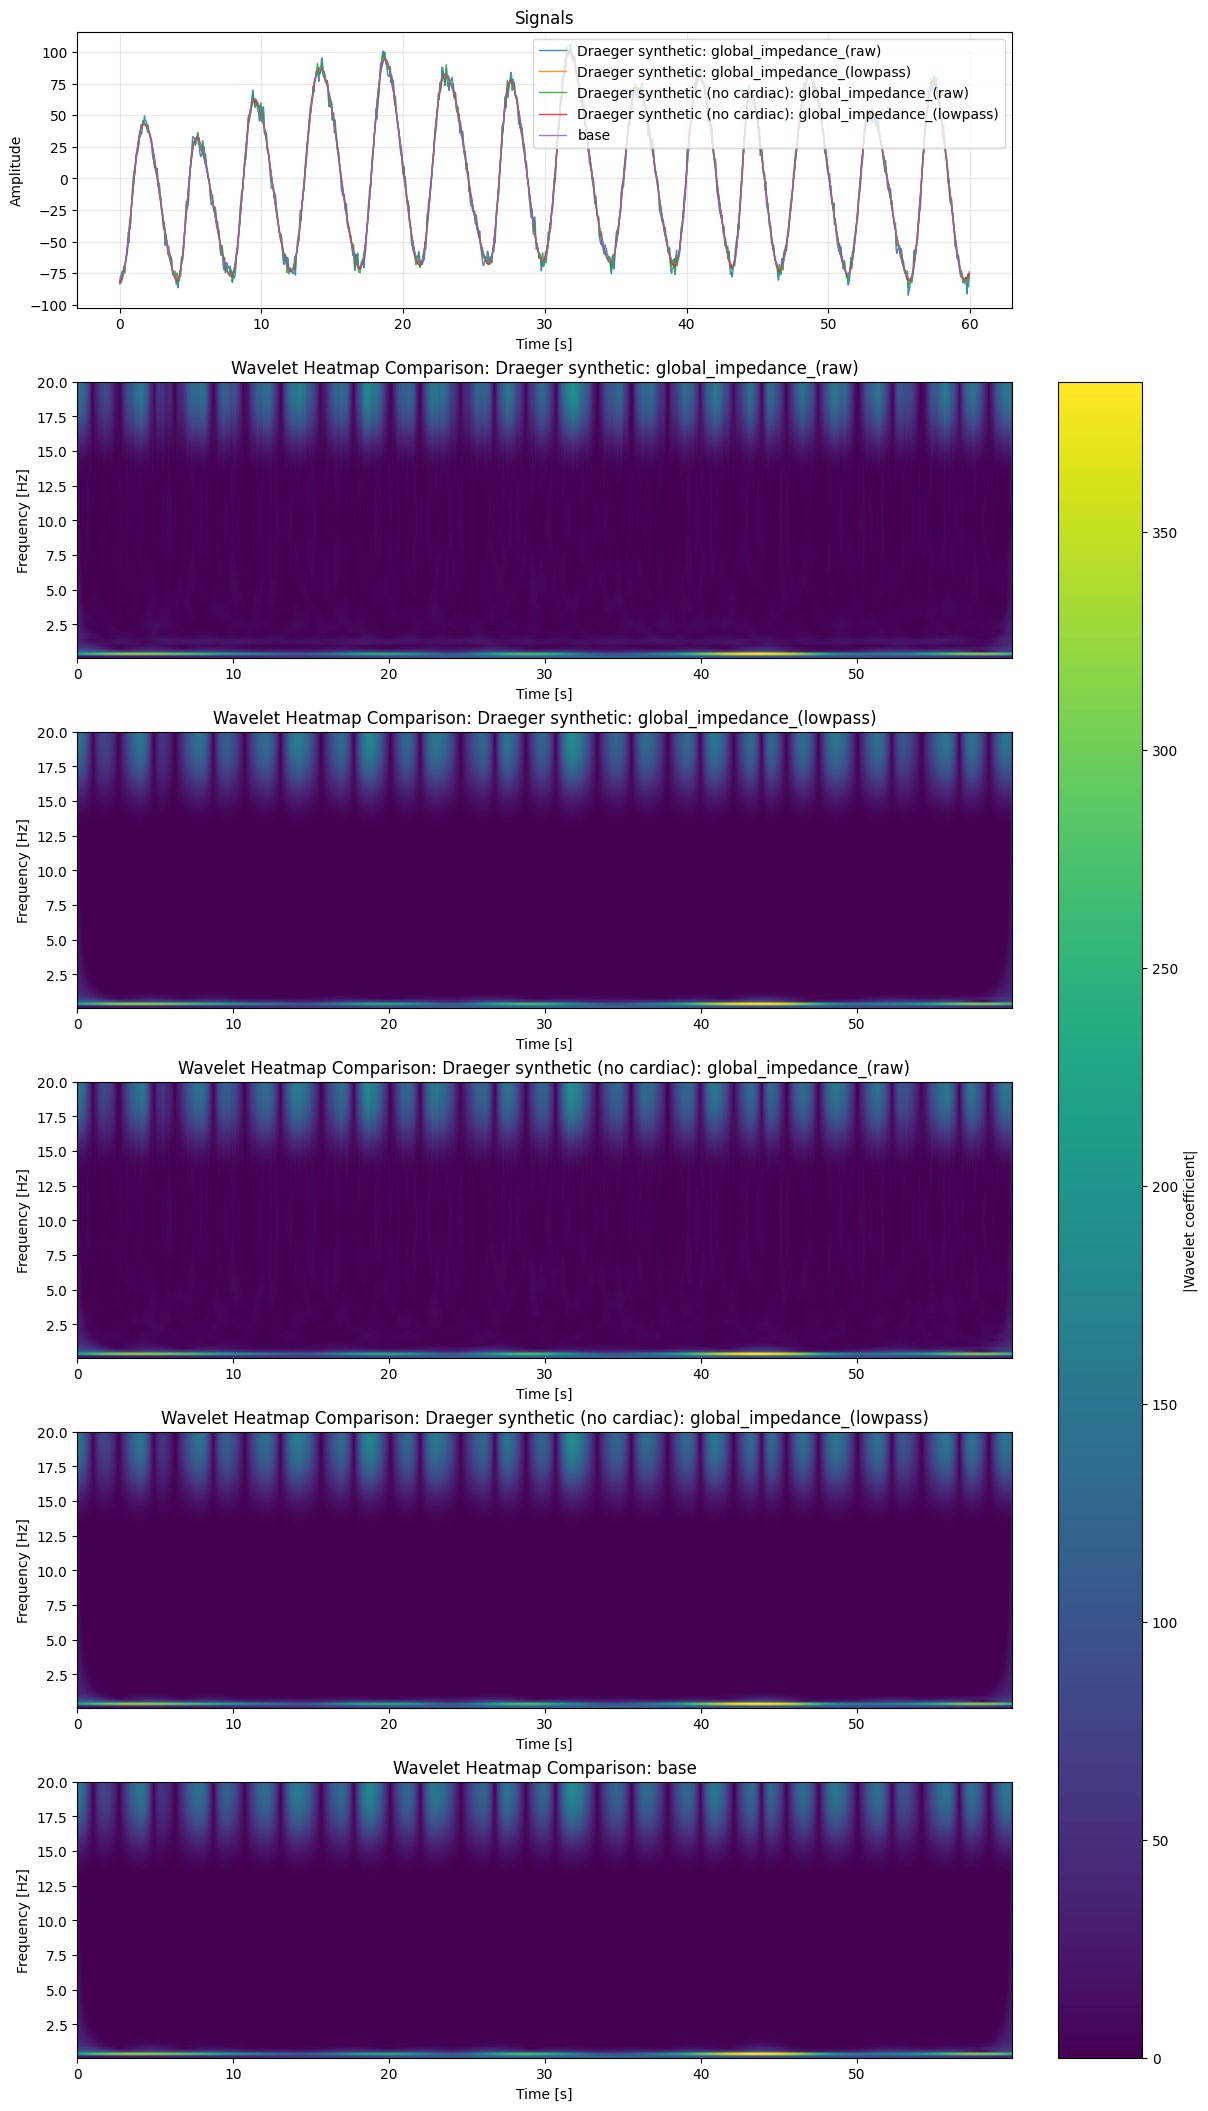

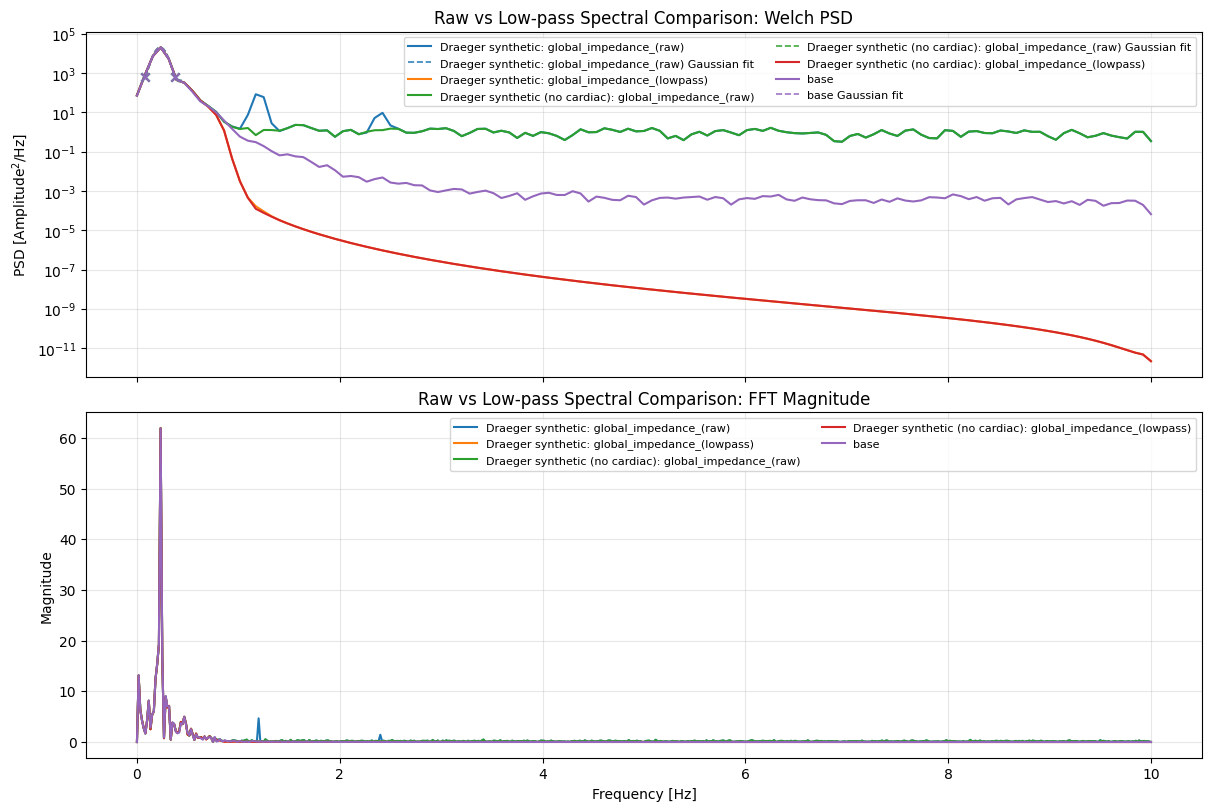

Gaussian fit summary for the first Welch PSD peak:
Draeger synthetic: global_impedance_(raw): mu=0.2295 Hz, sigma=0.0500 Hz, -3sigma=(0.0794 Hz, 634.474), +3sigma=(0.3795 Hz, 634.474)
Draeger synthetic (no cardiac): global_impedance_(raw): mu=0.2295 Hz, sigma=0.0500 Hz, -3sigma=(0.0794 Hz, 632.922), +3sigma=(0.3795 Hz, 632.922)
base: mu=0.2293 Hz, sigma=0.0500 Hz, -3sigma=(0.0793 Hz, 630.833), +3sigma=(0.3794 Hz, 630.833)


In [117]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fft, optimize, signal


def morlet_wavelet(scale: float, fs: float, w0: float = 6.0):
    """
    Create a complex Morlet wavelet at a given scale.
    """
    dt = 1.0 / fs
    half_width = int(np.ceil(4 * scale * fs))
    t = np.arange(-half_width, half_width + 1) * dt

    psi = np.exp(1j * w0 * (t / scale)) * np.exp(-(t ** 2) / (2 * scale ** 2))
    psi /= np.sqrt(np.sum(np.abs(psi) ** 2))

    return psi


def cwt_scipy(x: np.ndarray, fs: float, freqs: np.ndarray, w0: float = 6.0):
    """
    Compute a CWT-like transform using SciPy FFT convolution and Morlet wavelets.
    """
    x = np.asarray(x, dtype=float).squeeze()
    coeffs = np.zeros((len(freqs), len(x)), dtype=np.complex128)

    for i, f in enumerate(freqs):
        scale = w0 / (2 * np.pi * f)
        psi = morlet_wavelet(scale=scale, fs=fs, w0=w0)
        coeffs[i, :] = signal.fftconvolve(x, np.conj(psi[::-1]), mode="same")

    return coeffs


def prepare_signal_entries(signal_entries):
    if not signal_entries:
        raise ValueError("signal_entries must contain at least one signal.")

    prepared_entries = []
    reference_length = None
    for entry in signal_entries:
        values = np.asarray(entry["values"], dtype=float).squeeze()
        if values.ndim != 1:
            raise ValueError(f"Signal '{entry['label']}' must be 1D.")
        if len(values) == 0:
            raise ValueError(f"Signal '{entry['label']}' is empty.")
        if reference_length is None:
            reference_length = len(values)
        elif len(values) != reference_length:
            raise ValueError("All signals must have the same length.")

        prepared_entries.append(
            {
                "label": entry["label"],
                "values": values,
                "fit_gaussian": bool(entry.get("fit_gaussian", False)),
            }
        )

    return prepared_entries


def gaussian_with_offset(x, amplitude, mean, sigma, offset):
    sigma = np.maximum(sigma, np.finfo(float).eps)
    return offset + amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)


def fit_gaussian_to_first_peak(freqs_psd, psd):
    positive_mask = freqs_psd > 0
    freqs_positive = freqs_psd[positive_mask]
    psd_positive = psd[positive_mask]

    if len(freqs_positive) < 5:
        return None

    peaks, _ = signal.find_peaks(psd_positive)
    if len(peaks) == 0:
        return None

    first_peak_idx = peaks[0]
    widths, _, left_ips, right_ips = signal.peak_widths(psd_positive, [first_peak_idx], rel_height=0.5)
    half_width = max(int(np.ceil(widths[0])), 2)

    left_idx = max(int(np.floor(left_ips[0])) - half_width, 0)
    right_idx = min(int(np.ceil(right_ips[0])) + half_width, len(freqs_positive) - 1)
    fit_freqs = freqs_positive[left_idx : right_idx + 1]
    fit_psd = psd_positive[left_idx : right_idx + 1]

    if len(fit_freqs) < 5:
        return None

    offset_guess = max(float(np.min(fit_psd)), np.finfo(float).eps)
    amplitude_guess = max(float(np.max(fit_psd) - offset_guess), np.finfo(float).eps)
    mean_guess = float(freqs_positive[first_peak_idx])
    sigma_guess = max(float((fit_freqs[-1] - fit_freqs[0]) / 6), np.finfo(float).eps)

    try:
        params, _ = optimize.curve_fit(
            gaussian_with_offset,
            fit_freqs,
            fit_psd,
            p0=[amplitude_guess, mean_guess, sigma_guess, offset_guess],
            bounds=(
                [0, fit_freqs[0], np.finfo(float).eps, 0],
                [np.inf, fit_freqs[-1], np.inf, np.inf],
            ),
            maxfev=10000,
        )
    except (RuntimeError, ValueError):
        return None

    amplitude, mean, sigma, offset = params
    x_fit = np.linspace(fit_freqs[0], fit_freqs[-1], 400)
    y_fit = gaussian_with_offset(x_fit, amplitude, mean, sigma, offset)

    three_sigma_left_x = mean - 3 * sigma
    three_sigma_right_x = mean + 3 * sigma
    three_sigma_y = gaussian_with_offset(three_sigma_left_x, amplitude, mean, sigma, offset)

    return {
        "amplitude": float(amplitude),
        "mean": float(mean),
        "sigma": float(sigma),
        "offset": float(offset),
        "x_fit": x_fit,
        "y_fit": y_fit,
        "three_sigma_left_x": float(three_sigma_left_x),
        "three_sigma_right_x": float(three_sigma_right_x),
        "three_sigma_y": float(three_sigma_y),
    }


def plot_wavelet_heatmap(
    signal_entries,
    fs,
    fmin=5.0,
    fmax=150.0,
    nfreqs=80,
    title="SciPy Morlet CWT Scalogram",
):
    """
    Plot signal overlays and one wavelet heatmap per signal.
    """
    prepared_entries = prepare_signal_entries(signal_entries)
    centered_entries = [
        {
            "label": entry["label"],
            "values": entry["values"] - np.mean(entry["values"]),
        }
        for entry in prepared_entries
    ]

    t = np.arange(len(centered_entries[0]["values"])) / fs
    freqs = np.linspace(fmin, fmax, nfreqs)
    powers = [
        np.abs(cwt_scipy(x=entry["values"], fs=fs, freqs=freqs, w0=6.0))
        for entry in centered_entries
    ]

    vmax = max(np.max(power) for power in powers)
    nrows = 1 + len(centered_entries)
    fig, axes = plt.subplots(nrows, 1, figsize=(12, 3.5 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes)

    for entry in centered_entries:
        axes[0].plot(t, entry["values"], linewidth=1.0, alpha=0.85, label=entry["label"])
    axes[0].set_title("Signals")
    axes[0].set_xlabel("Time [s]")
    axes[0].set_ylabel("Amplitude")
    axes[0].legend(loc="upper right")
    axes[0].grid(True, alpha=0.3)

    last_im = None
    for idx, (entry, power) in enumerate(zip(centered_entries, powers, strict=True), start=1):
        last_im = axes[idx].imshow(
            power,
            extent=[t[0], t[-1], freqs[0], freqs[-1]],
            aspect="auto",
            origin="lower",
            vmin=0,
            vmax=vmax,
        )
        axes[idx].set_title(f"{title}: {entry['label']}")
        axes[idx].set_xlabel("Time [s]")
        axes[idx].set_ylabel("Frequency [Hz]")

    fig.colorbar(last_im, ax=axes[1:], label="|Wavelet coefficient|")
    plt.show()


def plot_psd_fft_comparison(
    signal_entries,
    fs,
    fmax=None,
    title="PSD and FFT Comparison",
):
    """
    Plot Welch PSD and FFT magnitude for multiple signals, and optionally fit
    a Gaussian bell curve to the first Welch peak of selected signals.
    """
    prepared_entries = prepare_signal_entries(signal_entries)

    if fmax is None:
        fmax = fs / 2

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
    gaussian_fit_results = []

    for entry in prepared_entries:
        centered = entry["values"] - np.mean(entry["values"])
        nperseg = min(256, len(centered))
        freqs_psd, psd = signal.welch(centered, fs=fs, nperseg=nperseg, detrend="constant")
        fft_freqs = fft.rfftfreq(len(centered), d=1.0 / fs)
        fft_magnitude = np.abs(fft.rfft(centered)) / len(centered)
        if len(fft_magnitude) > 2:
            fft_magnitude[1:-1] *= 2

        psd_mask = freqs_psd <= fmax
        fft_mask = fft_freqs <= fmax
        freqs_psd_masked = freqs_psd[psd_mask]
        psd_masked = psd[psd_mask]

        psd_line = axes[0].semilogy(freqs_psd_masked, psd_masked, linewidth=1.5, label=entry["label"])[0]
        axes[1].plot(fft_freqs[fft_mask], fft_magnitude[fft_mask], linewidth=1.5, label=entry["label"])

        if entry["fit_gaussian"]:
            fit_result = fit_gaussian_to_first_peak(freqs_psd_masked, psd_masked)
            if fit_result is not None:
                fit_result["label"] = entry["label"]
                gaussian_fit_results.append(fit_result)
                fit_color = psd_line.get_color()
                axes[0].semilogy(
                    fit_result["x_fit"],
                    fit_result["y_fit"],
                    linestyle="--",
                    linewidth=1.2,
                    color=fit_color,
                    alpha=0.9,
                    label=f"{entry['label']} Gaussian fit",
                )
                axes[0].scatter(
                    [fit_result["three_sigma_left_x"], fit_result["three_sigma_right_x"]],
                    [fit_result["three_sigma_y"], fit_result["three_sigma_y"]],
                    color=fit_color,
                    marker="x",
                    s=35,
                    zorder=4,
                )

    axes[0].set_title(f"{title}: Welch PSD")
    axes[0].set_ylabel("PSD [Amplitude$^2$/Hz]")
    axes[0].legend(fontsize=8, ncol=2)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title(f"{title}: FFT Magnitude")
    axes[1].set_xlabel("Frequency [Hz]")
    axes[1].set_ylabel("Magnitude")
    axes[1].legend(fontsize=8, ncol=2)
    axes[1].grid(True, alpha=0.3)

    plt.show()

    if gaussian_fit_results:
        print("Gaussian fit summary for the first Welch PSD peak:")
        for result in gaussian_fit_results:
            print(
                f"{result['label']}: "
                f"mu={result['mean']:.4f} Hz, "
                f"sigma={result['sigma']:.4f} Hz, "
                f"-3sigma=({result['three_sigma_left_x']:.4f} Hz, {result['three_sigma_y']:.6g}), "
                f"+3sigma=({result['three_sigma_right_x']:.4f} Hz, {result['three_sigma_y']:.6g})"
            )

    return gaussian_fit_results


signal_entries = [
    {
        "label": f"{dataset_results['draeger']['dataset_label']}: {raw_signal_data.label}",
        "values": raw_signal_data.values,
        "fit_gaussian": True,
    },
    {
        "label": f"{dataset_results['draeger']['dataset_label']}: {filtered_signal_data.label}",
        "values": filtered_signal_data.values,
        "fit_gaussian": False,
    },
    {
        "label": f"{dataset_results['draeger_no_cardiac']['dataset_label']}: {raw_signal_data_no_cardiac.label}",
        "values": raw_signal_data_no_cardiac.values,
        "fit_gaussian": True,
    },
    {
        "label": f"{dataset_results['draeger_no_cardiac']['dataset_label']}: {filtered_signal_data_no_cardiac.label}",
        "values": filtered_signal_data_no_cardiac.values,
        "fit_gaussian": False,
    },
    {
        "label": base_dataset_label,
        "values": raw_signal_data_base.values,
        "fit_gaussian": True,
    },
]

x = raw_signal_data.values
compare_x = filtered_signal_data.values
x_no_cardiac = raw_signal_data_no_cardiac.values
compare_x_no_cardiac = filtered_signal_data_no_cardiac.values
fs = raw_signal_data.sample_frequency
fs_no_cardiac = raw_signal_data_no_cardiac.sample_frequency

if fs is None or fs_no_cardiac is None:
    raise ValueError("The selected signals must have a sample_frequency.")
if not np.isclose(fs, fs_no_cardiac):
    raise ValueError("Both datasets must share the same sampling frequency for direct comparison.")

plot_wavelet_heatmap(
    signal_entries=signal_entries,
    fs=fs,
    fmin=0.1,
    fmax=20.0,
    nfreqs=100,
    title="Wavelet Heatmap Comparison",
)

psd_gaussian_fit_results = plot_psd_fft_comparison(
    signal_entries=signal_entries,
    fs=fs,
    fmax=20.0,
    title="Raw vs Low-pass Spectral Comparison",
)


Wavelet auto-tuning is minimizing full-spectrum PSD error against the base signal.
Selected wavelet denoising parameters:
{'levels': 7, 'preserve_below_frequency': 0.8, 'threshold_scale': 0.7375051708273099, 'low_band_threshold_scale': 0.0, 'score': -6.098036473975619, 'correlation': 0.9950485648830425, 'total_variation_error': 0.024773910396051566, 'std_error': 0.005651975075479133, 'psd_log_mse': 0.22121318009083038, 'psd_log_mae': 0.3351555864810908, 'psd_log_max_abs_error': 1.5220063151862044, 'psd_normalized_l2_error': 0.034913737477138614, 'psd_log_correlation': 0.9673095382190763}
Top 5 wavelet tuning candidates:
{'levels': 7, 'preserve_below_frequency': 0.8, 'threshold_scale': 0.7375051708273099, 'low_band_threshold_scale': 0.0, 'score': -6.098036, 'psd_log_mse': 0.22121318, 'psd_log_mae': 0.33515559, 'psd_log_max_abs_error': 1.52200632, 'psd_normalized_l2_error': 0.03491374, 'psd_log_correlation': 0.96730954, 'correlation': 0.995049, 'total_variation_error': 0.024774, 'std_err

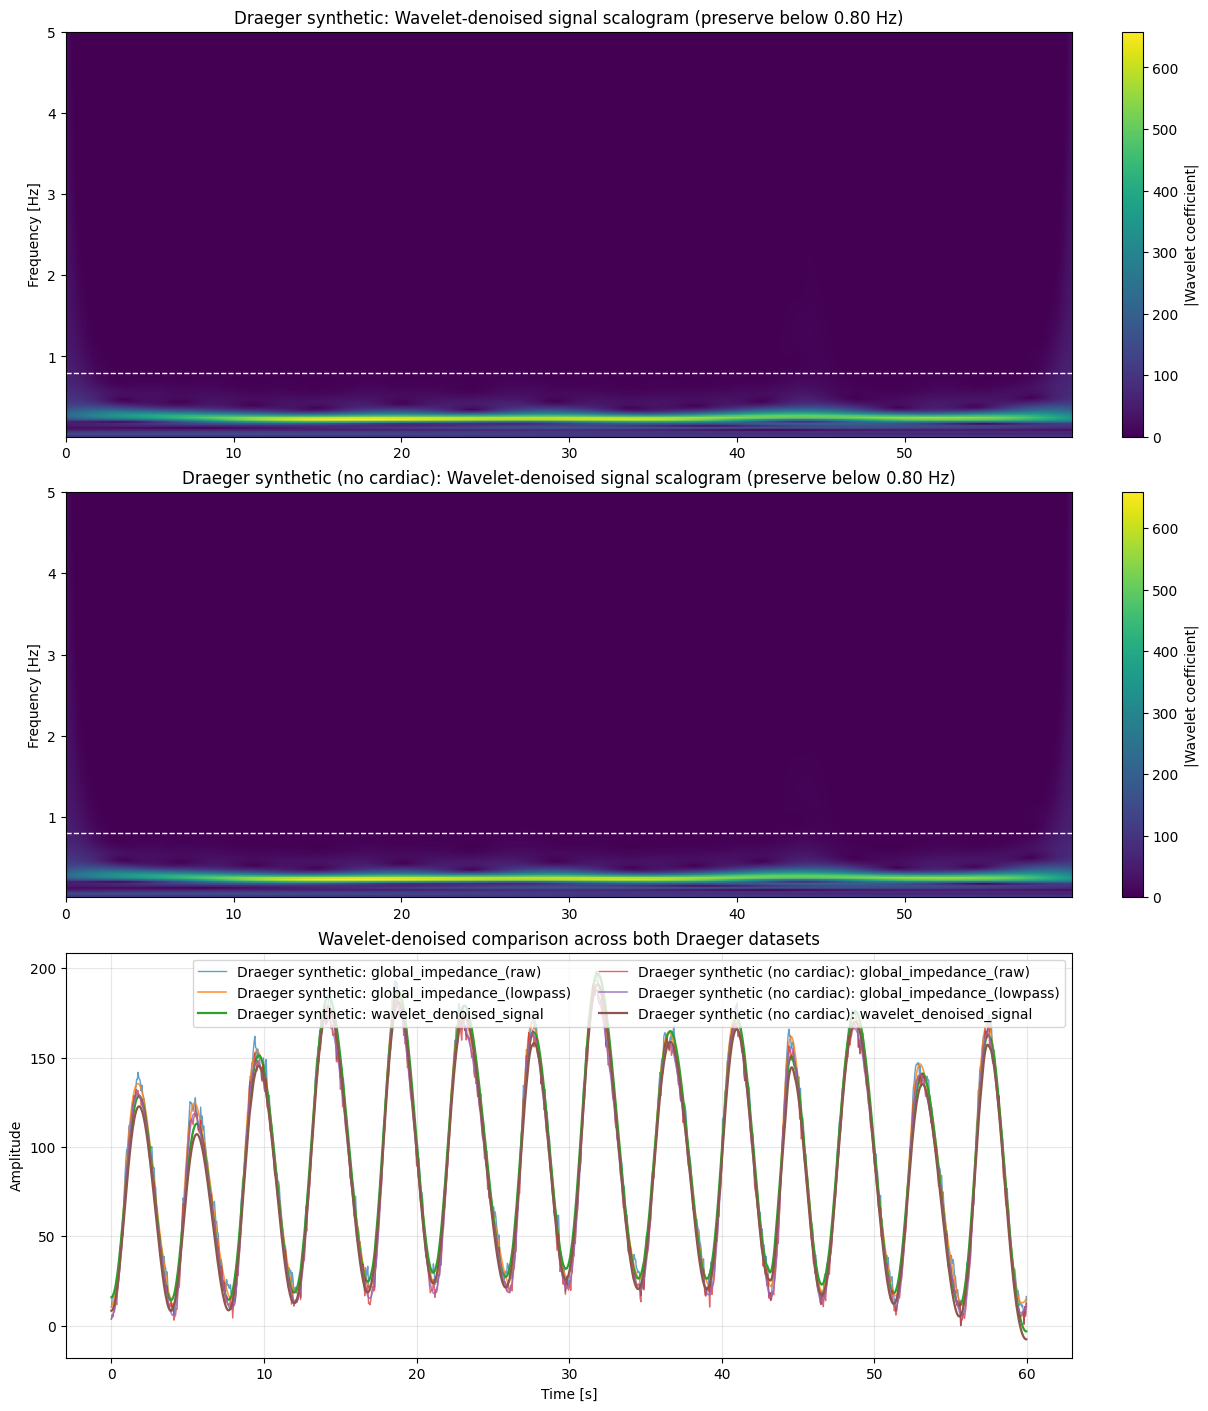

Wavelet denoising detail bands for the original dataset:
Level 1: 5.000-10.000 Hz, sigma=2.28271, threshold=6.33951
Level 2: 2.500-5.000 Hz, sigma=1.47256, threshold=4.08958
Level 3: 1.250-2.500 Hz, sigma=3.10184, threshold=8.6144
Level 4: 0.625-1.250 Hz, sigma=10.0046, threshold=13.8923
Level 5: 0.312-0.625 Hz, sigma=29.8116, threshold=0
Level 6: 0.156-0.312 Hz, sigma=25.3015, threshold=0
Level 7: 0.078-0.156 Hz, sigma=3.50355, threshold=0


In [118]:
def atrous_detail_band(fs, level):
    high_frequency = fs / (2**level)
    low_frequency = fs / (2 ** (level + 1))
    return low_frequency, high_frequency


def atrous_smooth_reflect(x, base_kernel, level):
    dilation = 2 ** (level - 1)
    dilated_kernel = np.zeros((len(base_kernel) - 1) * dilation + 1, dtype=float)
    dilated_kernel[::dilation] = base_kernel
    pad = len(dilated_kernel) // 2
    padded = np.pad(x, pad, mode="reflect")
    return signal.convolve(padded, dilated_kernel, mode="valid", method="auto")


def atrous_wavelet_decompose(x, levels=6, base_kernel=None):
    if base_kernel is None:
        base_kernel = np.array([1, 4, 6, 4, 1], dtype=float) / 16.0

    approximation = np.asarray(x, dtype=float).squeeze()
    if approximation.ndim != 1:
        raise ValueError("Input signal must be 1D.")

    detail_coefficients = []
    for level in range(1, levels + 1):
        smoothed = atrous_smooth_reflect(approximation, base_kernel=base_kernel, level=level)
        detail = approximation - smoothed
        detail_coefficients.append(detail)
        approximation = smoothed

    return approximation, detail_coefficients


def soft_threshold(values, threshold):
    return np.sign(values) * np.maximum(np.abs(values) - threshold, 0.0)


def wavelet_denoise_signal(
    x,
    fs,
    levels=6,
    preserve_below_frequency=0.8,
    threshold_scale=0.55,
    low_band_threshold_scale=0.05,
):
    """
    Denoise the signal with a multiscale a trous wavelet transform.

    High-frequency detail levels receive stronger soft-thresholding, while
    low-frequency levels near the breathing band are preserved much more gently.
    This produces a smoother approximation than the earlier CWT coefficient
    masking approach, which had no stable inverse reconstruction.
    """
    x = np.asarray(x, dtype=float).squeeze()
    if x.ndim != 1:
        raise ValueError("Input signal must be 1D.")
    if len(x) == 0:
        raise ValueError("Input signal is empty.")
    if fs <= 0:
        raise ValueError("Sampling frequency must be positive.")
    if levels < 1:
        raise ValueError("levels must be at least 1.")
    if preserve_below_frequency <= 0:
        raise ValueError("preserve_below_frequency must be positive.")

    centered = x - np.mean(x)
    approximation, details = atrous_wavelet_decompose(centered, levels=levels)

    denoised_details = []
    detail_summaries = []
    for level, detail in enumerate(details, start=1):
        band_low, band_high = atrous_detail_band(fs, level)
        sigma = np.median(np.abs(detail)) / 0.6745 if np.any(detail) else 0.0

        if sigma <= np.finfo(float).eps:
            threshold = 0.0
            denoised_detail = detail.copy()
        else:
            universal_threshold = sigma * np.sqrt(2.0 * np.log(len(detail)))
            if band_high <= preserve_below_frequency:
                threshold = low_band_threshold_scale * threshold_scale * universal_threshold
            elif band_low >= preserve_below_frequency:
                threshold = threshold_scale * universal_threshold
            else:
                threshold = 0.5 * threshold_scale * universal_threshold

            denoised_detail = soft_threshold(detail, threshold)

        denoised_details.append(denoised_detail)
        detail_summaries.append(
            {
                "level": level,
                "band_low": float(band_low),
                "band_high": float(band_high),
                "sigma": float(sigma),
                "threshold": float(threshold),
            }
        )

    reconstructed_centered = approximation + np.sum(denoised_details, axis=0)

    if np.any(reconstructed_centered):
        denominator = np.dot(reconstructed_centered, reconstructed_centered)
        if denominator > 0:
            alpha = np.dot(centered, reconstructed_centered) / denominator
            reconstructed_centered = alpha * reconstructed_centered

    reconstructed = reconstructed_centered + np.mean(x)
    return reconstructed, detail_summaries


def compute_welch_psd(x, fs, fmax=None, nperseg=256):
    centered = np.asarray(x, dtype=float).squeeze() - np.mean(x)
    nperseg = min(nperseg, len(centered))
    freqs_psd, psd = signal.welch(centered, fs=fs, nperseg=nperseg, detrend="constant")
    if fmax is None:
        fmax = fs / 2
    mask = freqs_psd <= min(fmax, fs / 2)
    return freqs_psd[mask], psd[mask]


def full_spectrum_psd_metrics(candidate_signal, reference_signal, fs, fmax=None):
    reference_freqs, reference_psd = compute_welch_psd(reference_signal, fs=fs, fmax=fmax)
    candidate_freqs, candidate_psd = compute_welch_psd(candidate_signal, fs=fs, fmax=fmax)

    if len(reference_freqs) != len(candidate_freqs) or not np.allclose(reference_freqs, candidate_freqs):
        candidate_psd = np.interp(reference_freqs, candidate_freqs, candidate_psd)
        candidate_freqs = reference_freqs

    eps = np.finfo(float).eps
    reference_log_psd = np.log10(reference_psd + eps)
    candidate_log_psd = np.log10(candidate_psd + eps)
    log_difference = candidate_log_psd - reference_log_psd

    if np.std(reference_log_psd) <= eps or np.std(candidate_log_psd) <= eps:
        psd_log_correlation = 1.0
    else:
        psd_log_correlation = float(np.corrcoef(candidate_log_psd, reference_log_psd)[0, 1])

    return {
        "psd_log_mse": float(np.mean(log_difference ** 2)),
        "psd_log_mae": float(np.mean(np.abs(log_difference))),
        "psd_log_max_abs_error": float(np.max(np.abs(log_difference))),
        "psd_normalized_l2_error": float(
            np.linalg.norm(candidate_psd - reference_psd) / max(np.linalg.norm(reference_psd), eps)
        ),
        "psd_log_correlation": float(psd_log_correlation),
    }


def evaluate_wavelet_denoise_params(
    raw_signal,
    reference_signal,
    fs,
    levels,
    preserve_below_frequency,
    threshold_scale,
    low_band_threshold_scale,
    psd_fmax=None,
):
    denoised_signal, _ = wavelet_denoise_signal(
        x=raw_signal,
        fs=fs,
        levels=levels,
        preserve_below_frequency=preserve_below_frequency,
        threshold_scale=threshold_scale,
        low_band_threshold_scale=low_band_threshold_scale,
    )

    reference_signal = np.asarray(reference_signal, dtype=float).squeeze()
    denoised_signal = np.asarray(denoised_signal, dtype=float).squeeze()

    correlation = float(np.corrcoef(denoised_signal, reference_signal)[0, 1])
    total_variation_reference = float(np.mean(np.abs(np.diff(reference_signal))))
    total_variation_denoised = float(np.mean(np.abs(np.diff(denoised_signal))))
    total_variation_error = abs(total_variation_denoised - total_variation_reference) / max(
        total_variation_reference,
        np.finfo(float).eps,
    )

    std_reference = float(np.std(reference_signal))
    std_denoised = float(np.std(denoised_signal))
    std_error = abs(std_denoised - std_reference) / max(std_reference, np.finfo(float).eps)

    psd_metrics = full_spectrum_psd_metrics(
        candidate_signal=denoised_signal,
        reference_signal=reference_signal,
        fs=fs,
        fmax=psd_fmax,
    )

    score = (
        -8.0 * psd_metrics["psd_log_mse"]
        -3.0 * psd_metrics["psd_log_max_abs_error"]
        -1.5 * psd_metrics["psd_normalized_l2_error"]
        +0.25 * psd_metrics["psd_log_correlation"]
        +0.05 * correlation
        -0.05 * total_variation_error
        -0.05 * std_error
    )

    return {
        "score": float(score),
        "correlation": float(correlation),
        "total_variation_error": float(total_variation_error),
        "std_error": float(std_error),
        "psd_log_mse": psd_metrics["psd_log_mse"],
        "psd_log_mae": psd_metrics["psd_log_mae"],
        "psd_log_max_abs_error": psd_metrics["psd_log_max_abs_error"],
        "psd_normalized_l2_error": psd_metrics["psd_normalized_l2_error"],
        "psd_log_correlation": psd_metrics["psd_log_correlation"],
    }


def auto_tune_wavelet_denoise(
    datasets,
    levels_grid,
    preserve_frequency_grid,
    threshold_scale_grid,
    low_band_threshold_scale_grid,
):
    tuning_results = []

    for levels in levels_grid:
        for preserve_below_frequency in preserve_frequency_grid:
            for threshold_scale in threshold_scale_grid:
                for low_band_threshold_scale in low_band_threshold_scale_grid:
                    metrics = []
                    for dataset in datasets:
                        metrics.append(
                            evaluate_wavelet_denoise_params(
                                raw_signal=dataset["raw_signal"],
                                reference_signal=dataset["reference_signal"],
                                fs=dataset["fs"],
                                levels=levels,
                                preserve_below_frequency=preserve_below_frequency,
                                threshold_scale=threshold_scale,
                                low_band_threshold_scale=low_band_threshold_scale,
                                psd_fmax=dataset.get("psd_fmax"),
                            )
                        )

                    aggregate_result = {
                        "levels": int(levels),
                        "preserve_below_frequency": float(preserve_below_frequency),
                        "threshold_scale": float(threshold_scale),
                        "low_band_threshold_scale": float(low_band_threshold_scale),
                        "score": float(np.mean([metric["score"] for metric in metrics])),
                        "correlation": float(np.mean([metric["correlation"] for metric in metrics])),
                        "total_variation_error": float(
                            np.mean([metric["total_variation_error"] for metric in metrics])
                        ),
                        "std_error": float(np.mean([metric["std_error"] for metric in metrics])),
                        "psd_log_mse": float(np.mean([metric["psd_log_mse"] for metric in metrics])),
                        "psd_log_mae": float(np.mean([metric["psd_log_mae"] for metric in metrics])),
                        "psd_log_max_abs_error": float(
                            np.mean([metric["psd_log_max_abs_error"] for metric in metrics])
                        ),
                        "psd_normalized_l2_error": float(
                            np.mean([metric["psd_normalized_l2_error"] for metric in metrics])
                        ),
                        "psd_log_correlation": float(
                            np.mean([metric["psd_log_correlation"] for metric in metrics])
                        ),
                    }
                    tuning_results.append(aggregate_result)

    tuning_results.sort(key=lambda result: result["score"], reverse=True)
    return tuning_results[0], tuning_results


def refine_wavelet_tuning_result(initial_result, dataset):
    def objective(params):
        metrics = evaluate_wavelet_denoise_params(
            raw_signal=dataset["raw_signal"],
            reference_signal=dataset["reference_signal"],
            fs=dataset["fs"],
            levels=initial_result["levels"],
            preserve_below_frequency=float(params[0]),
            threshold_scale=float(params[1]),
            low_band_threshold_scale=float(params[2]),
            psd_fmax=dataset.get("psd_fmax"),
        )
        return -metrics["score"]

    optimization_result = optimize.minimize(
        objective,
        x0=[
            initial_result["preserve_below_frequency"],
            initial_result["threshold_scale"],
            initial_result["low_band_threshold_scale"],
        ],
        method="L-BFGS-B",
        bounds=[
            (0.2, 1.5),
            (0.0, 1.0),
            (0.0, 0.2),
        ],
        options={"maxiter": 60},
    )

    if not optimization_result.success:
        return initial_result

    refined_metrics = evaluate_wavelet_denoise_params(
        raw_signal=dataset["raw_signal"],
        reference_signal=dataset["reference_signal"],
        fs=dataset["fs"],
        levels=initial_result["levels"],
        preserve_below_frequency=float(optimization_result.x[0]),
        threshold_scale=float(optimization_result.x[1]),
        low_band_threshold_scale=float(optimization_result.x[2]),
        psd_fmax=dataset.get("psd_fmax"),
    )
    refined_result = {
        "levels": int(initial_result["levels"]),
        "preserve_below_frequency": float(optimization_result.x[0]),
        "threshold_scale": float(optimization_result.x[1]),
        "low_band_threshold_scale": float(optimization_result.x[2]),
        **refined_metrics,
    }
    if refined_result["score"] > initial_result["score"]:
        return refined_result
    return initial_result


use_auto_wavelet_tuning = True
wavelet_tuning_datasets = [
    {
        "label": dataset_results["draeger"]["dataset_label"],
        "raw_signal": x,
        "reference_signal": raw_signal_data_base.values,
        "fs": fs,
        "psd_fmax": 20.0,
    },
]
wavelet_denoise_levels_grid = [4, 5, 6, 7, 8, 9]
wavelet_preserve_below_frequency_grid = [0.4, 0.6, 0.8, 1.0, 1.2]
wavelet_threshold_scale_grid = [0.1, 0.2, 0.3, 0.4, 0.55, 0.7, 0.85]
wavelet_low_band_threshold_scale_grid = [0.0, 0.01, 0.02, 0.05, 0.08, 0.12]

if use_auto_wavelet_tuning:
    best_wavelet_params, wavelet_tuning_results = auto_tune_wavelet_denoise(
        datasets=wavelet_tuning_datasets,
        levels_grid=wavelet_denoise_levels_grid,
        preserve_frequency_grid=wavelet_preserve_below_frequency_grid,
        threshold_scale_grid=wavelet_threshold_scale_grid,
        low_band_threshold_scale_grid=wavelet_low_band_threshold_scale_grid,
    )
    best_wavelet_params = refine_wavelet_tuning_result(
        initial_result=best_wavelet_params,
        dataset=wavelet_tuning_datasets[0],
    )
    wavelet_tuning_results = sorted(
        [best_wavelet_params, *wavelet_tuning_results],
        key=lambda result: result["score"],
        reverse=True,
    )
    wavelet_denoise_levels = best_wavelet_params["levels"]
    wavelet_preserve_below_frequency = best_wavelet_params["preserve_below_frequency"]
    wavelet_threshold_scale = best_wavelet_params["threshold_scale"]
    wavelet_low_band_threshold_scale = best_wavelet_params["low_band_threshold_scale"]
else:
    wavelet_denoise_levels = 8
    wavelet_preserve_below_frequency = 0.8
    wavelet_threshold_scale = 0.2
    wavelet_low_band_threshold_scale = 0.0
    wavelet_tuning_results = []
    best_wavelet_params = {
        "levels": wavelet_denoise_levels,
        "preserve_below_frequency": wavelet_preserve_below_frequency,
        "threshold_scale": wavelet_threshold_scale,
        "low_band_threshold_scale": wavelet_low_band_threshold_scale,
    }

wavelet_plot_fmin = 0.01
wavelet_plot_fmax = 5.0
wavelet_plot_nfreqs = 200

print("Wavelet auto-tuning is minimizing full-spectrum PSD error against the base signal.")
print("Selected wavelet denoising parameters:")
print(best_wavelet_params)
if wavelet_tuning_results:
    print("Top 5 wavelet tuning candidates:")
    for result in wavelet_tuning_results[:5]:
        print(
            {
                "levels": result["levels"],
                "preserve_below_frequency": result["preserve_below_frequency"],
                "threshold_scale": result["threshold_scale"],
                "low_band_threshold_scale": result["low_band_threshold_scale"],
                "score": round(result["score"], 6),
                "psd_log_mse": round(result["psd_log_mse"], 8),
                "psd_log_mae": round(result["psd_log_mae"], 8),
                "psd_log_max_abs_error": round(result["psd_log_max_abs_error"], 8),
                "psd_normalized_l2_error": round(result["psd_normalized_l2_error"], 8),
                "psd_log_correlation": round(result["psd_log_correlation"], 8),
                "correlation": round(result["correlation"], 6),
                "total_variation_error": round(result["total_variation_error"], 6),
                "std_error": round(result["std_error"], 6),
            }
        )


filtered_signal_data_new, wavelet_detail_summary = wavelet_denoise_signal(
    x=x,
    fs=fs,
    levels=wavelet_denoise_levels,
    preserve_below_frequency=wavelet_preserve_below_frequency,
    threshold_scale=wavelet_threshold_scale,
    low_band_threshold_scale=wavelet_low_band_threshold_scale,
)
filtered_signal_data_new_no_cardiac, wavelet_detail_summary_no_cardiac = wavelet_denoise_signal(
    x=x_no_cardiac,
    fs=fs_no_cardiac,
    levels=wavelet_denoise_levels,
    preserve_below_frequency=wavelet_preserve_below_frequency,
    threshold_scale=wavelet_threshold_scale,
    low_band_threshold_scale=wavelet_low_band_threshold_scale,
)

wavelet_freqs = np.linspace(wavelet_plot_fmin, wavelet_plot_fmax, wavelet_plot_nfreqs)
wavelet_freqs_no_cardiac = np.linspace(wavelet_plot_fmin, wavelet_plot_fmax, wavelet_plot_nfreqs)

filtered_wavelet_amplitude = np.abs(
    cwt_scipy(
        x=filtered_signal_data_new - np.mean(filtered_signal_data_new),
        fs=fs,
        freqs=wavelet_freqs,
        w0=6.0,
    )
)
filtered_wavelet_amplitude_no_cardiac = np.abs(
    cwt_scipy(
        x=filtered_signal_data_new_no_cardiac - np.mean(filtered_signal_data_new_no_cardiac),
        fs=fs_no_cardiac,
        freqs=wavelet_freqs_no_cardiac,
        w0=6.0,
    )
)

wavelet_vmax = max(
    np.max(filtered_wavelet_amplitude),
    np.max(filtered_wavelet_amplitude_no_cardiac),
)

fig, axes = plt.subplots(3, 1, figsize=(12, 14), constrained_layout=True, sharex=False)

im_original = axes[0].imshow(
    filtered_wavelet_amplitude,
    extent=[raw_signal_data.time[0], raw_signal_data.time[-1], wavelet_freqs[0], wavelet_freqs[-1]],
    aspect="auto",
    origin="lower",
    vmin=0,
    vmax=wavelet_vmax,
)
axes[0].axhline(wavelet_preserve_below_frequency, color="white", linestyle="--", linewidth=1.0)
axes[0].set_title(
    f"{dataset_results['draeger']['dataset_label']}: Wavelet-denoised signal scalogram "
    f"(preserve below {wavelet_preserve_below_frequency:.2f} Hz)"
)
axes[0].set_ylabel("Frequency [Hz]")
fig.colorbar(im_original, ax=axes[0], label="|Wavelet coefficient|")

im_no_cardiac = axes[1].imshow(
    filtered_wavelet_amplitude_no_cardiac,
    extent=[
        raw_signal_data_no_cardiac.time[0],
        raw_signal_data_no_cardiac.time[-1],
        wavelet_freqs_no_cardiac[0],
        wavelet_freqs_no_cardiac[-1],
    ],
    aspect="auto",
    origin="lower",
    vmin=0,
    vmax=wavelet_vmax,
)
axes[1].axhline(wavelet_preserve_below_frequency, color="white", linestyle="--", linewidth=1.0)
axes[1].set_title(
    f"{dataset_results['draeger_no_cardiac']['dataset_label']}: Wavelet-denoised signal scalogram "
    f"(preserve below {wavelet_preserve_below_frequency:.2f} Hz)"
)
axes[1].set_ylabel("Frequency [Hz]")
fig.colorbar(im_no_cardiac, ax=axes[1], label="|Wavelet coefficient|")

axes[2].plot(
    raw_signal_data.time,
    raw_signal_data.values,
    linewidth=1.0,
    alpha=0.7,
    label=f"{dataset_results['draeger']['dataset_label']}: {raw_signal_data.label}",
)
axes[2].plot(
    filtered_signal_data.time,
    filtered_signal_data.values,
    linewidth=1.2,
    alpha=0.8,
    label=f"{dataset_results['draeger']['dataset_label']}: {filtered_signal_data.label}",
)
axes[2].plot(
    raw_signal_data.time,
    filtered_signal_data_new,
    linewidth=1.6,
    label=f"{dataset_results['draeger']['dataset_label']}: wavelet_denoised_signal",
)
axes[2].plot(
    raw_signal_data_no_cardiac.time,
    raw_signal_data_no_cardiac.values,
    linewidth=1.0,
    alpha=0.7,
    label=f"{dataset_results['draeger_no_cardiac']['dataset_label']}: {raw_signal_data_no_cardiac.label}",
)
axes[2].plot(
    filtered_signal_data_no_cardiac.time,
    filtered_signal_data_no_cardiac.values,
    linewidth=1.2,
    alpha=0.8,
    label=f"{dataset_results['draeger_no_cardiac']['dataset_label']}: {filtered_signal_data_no_cardiac.label}",
)
axes[2].plot(
    raw_signal_data_no_cardiac.time,
    filtered_signal_data_new_no_cardiac,
    linewidth=1.6,
    label=f"{dataset_results['draeger_no_cardiac']['dataset_label']}: wavelet_denoised_signal",
)
axes[2].set_title("Wavelet-denoised comparison across both Draeger datasets")
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Amplitude")
axes[2].legend(loc="upper right", ncol=2)
axes[2].grid(True, alpha=0.3)

plt.show()

print("Wavelet denoising detail bands for the original dataset:")
for summary in wavelet_detail_summary:
    print(
        f"Level {summary['level']}: "
        f"{summary['band_low']:.3f}-{summary['band_high']:.3f} Hz, "
        f"sigma={summary['sigma']:.6g}, threshold={summary['threshold']:.6g}"
    )

import plotly.graph_objects as go
import plotly.io as pio

plotly_wavelet_comparison = go.Figure()
plotly_wavelet_comparison.add_scatter(
    x=raw_signal_data.time,
    y=raw_signal_data.values,
    mode="lines",
    name=f"{dataset_results['draeger']['dataset_label']}: {raw_signal_data.label}",
)
plotly_wavelet_comparison.add_scatter(
    x=filtered_signal_data.time,
    y=filtered_signal_data.values,
    mode="lines",
    name=f"{dataset_results['draeger']['dataset_label']}: {filtered_signal_data.label}",
)
plotly_wavelet_comparison.add_scatter(
    x=raw_signal_data.time,
    y=filtered_signal_data_new,
    mode="lines",
    name=f"{dataset_results['draeger']['dataset_label']}: wavelet_denoised_signal",
)
plotly_wavelet_comparison.add_scatter(
    x=raw_signal_data_no_cardiac.time,
    y=raw_signal_data_no_cardiac.values,
    mode="lines",
    name=f"{dataset_results['draeger_no_cardiac']['dataset_label']}: {raw_signal_data_no_cardiac.label}",
)
plotly_wavelet_comparison.add_scatter(
    x=filtered_signal_data_no_cardiac.time,
    y=filtered_signal_data_no_cardiac.values,
    mode="lines",
    name=f"{dataset_results['draeger_no_cardiac']['dataset_label']}: {filtered_signal_data_no_cardiac.label}",
)
plotly_wavelet_comparison.add_scatter(
    x=raw_signal_data_no_cardiac.time,
    y=filtered_signal_data_new_no_cardiac,
    mode="lines",
    name=f"{dataset_results['draeger_no_cardiac']['dataset_label']}: wavelet_denoised_signal",
)
plotly_wavelet_comparison.add_scatter(
    x=raw_signal_data_base.time,
    y=raw_signal_data_base.values,
    mode="lines",
    name=base_dataset_label,
)
plotly_wavelet_comparison.update_layout(
    title=(
        "Wavelet-denoised comparison across both Draeger datasets "
        f"(Plotly, preserve below {wavelet_preserve_below_frequency:.2f} Hz)"
    ),
    xaxis_title="Time [s]",
    yaxis_title="Amplitude",
    template="plotly_white",
    hovermode="x unified",
)

try:
    from IPython.display import HTML, display

    display(HTML(pio.to_html(plotly_wavelet_comparison, include_plotlyjs="cdn", full_html=False)))
except Exception:
    pio.write_html(plotly_wavelet_comparison, file="plotly_wavelet_comparison.html", auto_open=False, include_plotlyjs="cdn")
    plotly_wavelet_comparison.show(renderer="browser")


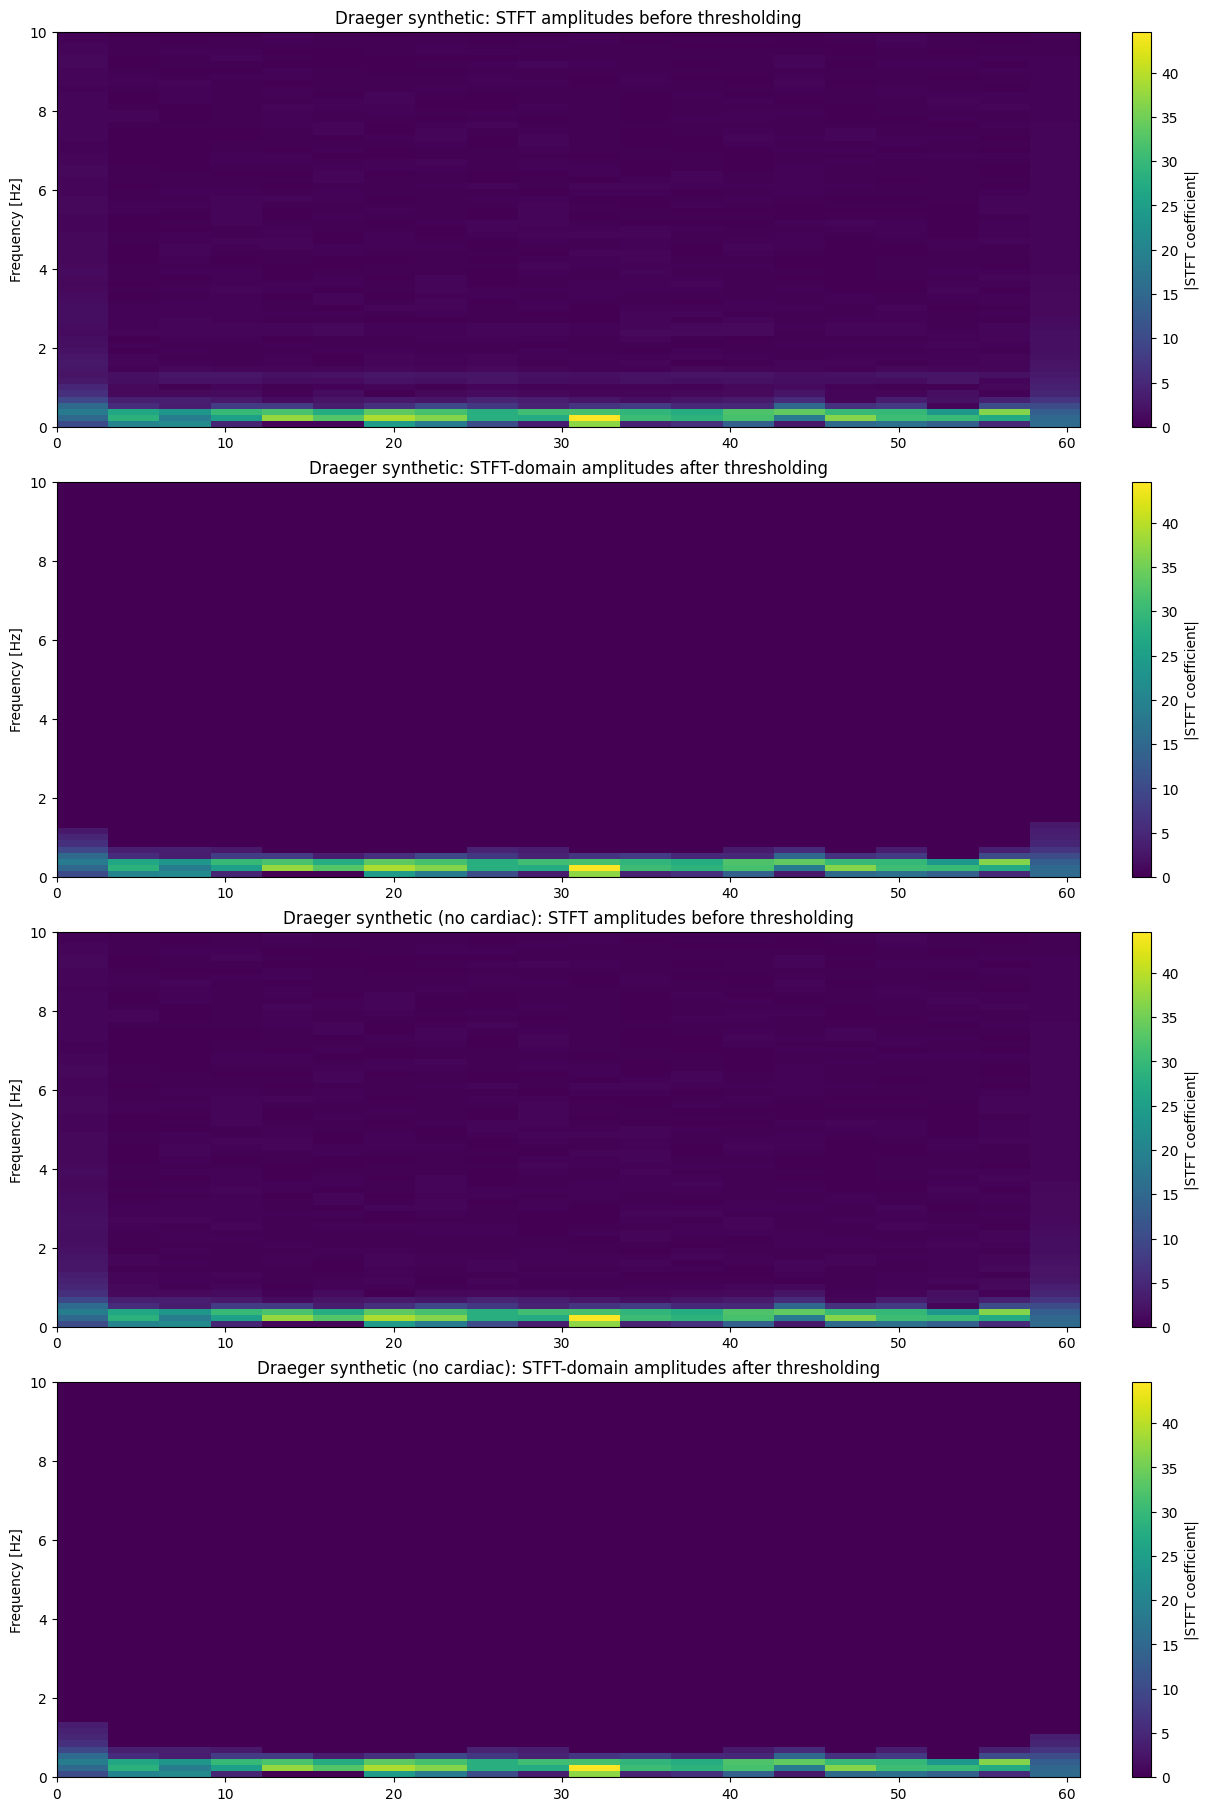

In [119]:
def stft_domain_threshold_filter(
    x,
    fs,
    amplitude_threshold=5,
    nperseg=128,
    noverlap=None,
):
    """
    Filter in the STFT domain by zeroing coefficients whose amplitude
    is below amplitude_threshold.
    """
    x = np.asarray(x, dtype=float).squeeze()
    if x.ndim != 1:
        raise ValueError("Input signal must be 1D.")
    if len(x) == 0:
        raise ValueError("Input signal is empty.")

    centered = x - np.mean(x)
    nperseg = min(nperseg, len(centered))
    if noverlap is None:
        noverlap = nperseg // 2

    stft_freqs, stft_times, stft_coeffs = signal.stft(
        centered,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        boundary="zeros",
        padded=True,
    )

    stft_amplitude = np.abs(stft_coeffs)
    filtered_coeffs = stft_coeffs.copy()
    filtered_coeffs[np.abs(filtered_coeffs) < amplitude_threshold] = 0

    _, reconstructed = signal.istft(
        filtered_coeffs,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        input_onesided=True,
        boundary=True,
    )
    reconstructed = np.real(reconstructed[: len(x)])

    if np.any(reconstructed):
        denominator = np.dot(reconstructed, reconstructed)
        if denominator > 0:
            alpha = np.dot(centered, reconstructed) / denominator
            reconstructed = alpha * reconstructed + np.mean(x)

    return reconstructed, stft_freqs, stft_times, stft_amplitude, np.abs(filtered_coeffs)

threshold = 3

filtered_signal_data_new_stft, stft_freqs, stft_times, stft_amplitude, filtered_stft_amplitude = (
    stft_domain_threshold_filter(
        x=x,
        fs=fs,
        amplitude_threshold=threshold,
        nperseg=128,
    )
)
(
    filtered_signal_data_new_stft_no_cardiac,
    stft_freqs_no_cardiac,
    stft_times_no_cardiac,
    stft_amplitude_no_cardiac,
    filtered_stft_amplitude_no_cardiac,
) = stft_domain_threshold_filter(
    x=x_no_cardiac,
    fs=fs_no_cardiac,
    amplitude_threshold=threshold,
    nperseg=128,
)

stft_vmax = max(
    np.max(stft_amplitude),
    np.max(filtered_stft_amplitude),
    np.max(stft_amplitude_no_cardiac),
    np.max(filtered_stft_amplitude_no_cardiac),
)

fig, axes = plt.subplots(4, 1, figsize=(12, 18), constrained_layout=True, sharex=False)

im_before = axes[0].imshow(
    stft_amplitude,
    extent=[stft_times[0], stft_times[-1], stft_freqs[0], stft_freqs[-1]],
    aspect="auto",
    origin="lower",
    vmin=0,
    vmax=stft_vmax,
)
axes[0].set_title(f"{dataset_results['draeger']['dataset_label']}: STFT amplitudes before thresholding")
axes[0].set_ylabel("Frequency [Hz]")
fig.colorbar(im_before, ax=axes[0], label="|STFT coefficient|")

im_after = axes[1].imshow(
    filtered_stft_amplitude,
    extent=[stft_times[0], stft_times[-1], stft_freqs[0], stft_freqs[-1]],
    aspect="auto",
    origin="lower",
    vmin=0,
    vmax=stft_vmax,
)
axes[1].set_title(f"{dataset_results['draeger']['dataset_label']}: STFT-domain amplitudes after thresholding")
axes[1].set_ylabel("Frequency [Hz]")
fig.colorbar(im_after, ax=axes[1], label="|STFT coefficient|")

im_before_no_cardiac = axes[2].imshow(
    stft_amplitude_no_cardiac,
    extent=[
        stft_times_no_cardiac[0],
        stft_times_no_cardiac[-1],
        stft_freqs_no_cardiac[0],
        stft_freqs_no_cardiac[-1],
    ],
    aspect="auto",
    origin="lower",
    vmin=0,
    vmax=stft_vmax,
)
axes[2].set_title(f"{dataset_results['draeger_no_cardiac']['dataset_label']}: STFT amplitudes before thresholding")
axes[2].set_ylabel("Frequency [Hz]")
fig.colorbar(im_before_no_cardiac, ax=axes[2], label="|STFT coefficient|")

im_after_no_cardiac = axes[3].imshow(
    filtered_stft_amplitude_no_cardiac,
    extent=[
        stft_times_no_cardiac[0],
        stft_times_no_cardiac[-1],
        stft_freqs_no_cardiac[0],
        stft_freqs_no_cardiac[-1],
    ],
    aspect="auto",
    origin="lower",
    vmin=0,
    vmax=stft_vmax,
)
axes[3].set_title(
    f"{dataset_results['draeger_no_cardiac']['dataset_label']}: STFT-domain amplitudes after thresholding"
)
axes[3].set_ylabel("Frequency [Hz]")
fig.colorbar(im_after_no_cardiac, ax=axes[3], label="|STFT coefficient|")

# axes[4].plot(
#     raw_signal_data.time,
#     raw_signal_data.values,
#     linewidth=1.0,
#     alpha=0.7,
#     label=f"{dataset_results['draeger']['dataset_label']}: {raw_signal_data.label}",
# )
# axes[4].plot(
#     filtered_signal_data.time,
#     filtered_signal_data.values,
#     linewidth=1.2,
#     alpha=0.8,
#     label=f"{dataset_results['draeger']['dataset_label']}: {filtered_signal_data.label}",
# )
# axes[4].plot(
#     raw_signal_data.time,
#     filtered_signal_data_new_stft,
#     linewidth=1.5,
#     label=f"{dataset_results['draeger']['dataset_label']}: filtered_signal_data_new_stft",
# )
# axes[4].plot(
#     raw_signal_data_no_cardiac.time,
#     raw_signal_data_no_cardiac.values,
#     linewidth=1.0,
#     alpha=0.7,
#     label=f"{dataset_results['draeger_no_cardiac']['dataset_label']}: {raw_signal_data_no_cardiac.label}",
# )
# axes[4].plot(
#     filtered_signal_data_no_cardiac.time,
#     filtered_signal_data_no_cardiac.values,
#     linewidth=1.2,
#     alpha=0.8,
#     label=f"{dataset_results['draeger_no_cardiac']['dataset_label']}: {filtered_signal_data_no_cardiac.label}",
# )
# axes[4].plot(
#     raw_signal_data_no_cardiac.time,
#     filtered_signal_data_new_stft_no_cardiac,
#     linewidth=1.5,
#     label=f"{dataset_results['draeger_no_cardiac']['dataset_label']}: filtered_signal_data_new_stft",
# )
# axes[4].set_title("STFT comparison across both Draeger datasets")
# axes[4].set_xlabel("Time [s]")
# axes[4].set_ylabel("Amplitude")
# axes[4].legend(loc="upper right", ncol=2)
# axes[4].grid(True, alpha=0.3)

plt.show()

import plotly.graph_objects as go
import plotly.io as pio

plotly_stft_comparison = go.Figure()
plotly_stft_comparison.add_scatter(
    x=raw_signal_data.time,
    y=raw_signal_data.values,
    mode="lines",
    name=f"{dataset_results['draeger']['dataset_label']}: {raw_signal_data.label}",
)
plotly_stft_comparison.add_scatter(
    x=filtered_signal_data.time,
    y=filtered_signal_data.values,
    mode="lines",
    name=f"{dataset_results['draeger']['dataset_label']}: {filtered_signal_data.label}",
)
plotly_stft_comparison.add_scatter(
    x=raw_signal_data.time,
    y=filtered_signal_data_new_stft,
    mode="lines",
    name=f"{dataset_results['draeger']['dataset_label']}: filtered_signal_data_new_stft",
)
plotly_stft_comparison.add_scatter(
    x=raw_signal_data_no_cardiac.time,
    y=raw_signal_data_no_cardiac.values,
    mode="lines",
    name=f"{dataset_results['draeger_no_cardiac']['dataset_label']}: {raw_signal_data_no_cardiac.label}",
)
plotly_stft_comparison.add_scatter(
    x=filtered_signal_data_no_cardiac.time,
    y=filtered_signal_data_no_cardiac.values,
    mode="lines",
    name=f"{dataset_results['draeger_no_cardiac']['dataset_label']}: {filtered_signal_data_no_cardiac.label}",
)
plotly_stft_comparison.add_scatter(
    x=raw_signal_data_no_cardiac.time,
    y=filtered_signal_data_new_stft_no_cardiac,
    mode="lines",
    name=f"{dataset_results['draeger_no_cardiac']['dataset_label']}: filtered_signal_data_new_stft",
)
plotly_stft_comparison.add_scatter(
    x=raw_signal_data_base.time,
    y=raw_signal_data_base.values,
    mode="lines",
    name=base_dataset_label,
)
plotly_stft_comparison.update_layout(
    title="STFT comparison across both Draeger datasets (Plotly)",
    xaxis_title="Time [s]",
    yaxis_title="Amplitude",
    template="plotly_white",
    hovermode="x unified",
)

try:
    from IPython.display import HTML, display

    display(HTML(pio.to_html(plotly_stft_comparison, include_plotlyjs="cdn", full_html=False)))
except Exception:
    pio.write_html(plotly_stft_comparison, file="plotly_stft_comparison.html", auto_open=False, include_plotlyjs="cdn")
    plotly_stft_comparison.show(renderer="browser")


In [120]:
from plotly.subplots import make_subplots

plotly_psd_fft_signal_entries = [
    {
        "label": f"{dataset_results['draeger']['dataset_label']}: {raw_signal_data.label}",
        "values": raw_signal_data.values,
    },
    {
        "label": f"{dataset_results['draeger']['dataset_label']}: {filtered_signal_data.label}",
        "values": filtered_signal_data.values,
    },
    {
        "label": f"{dataset_results['draeger']['dataset_label']}: wavelet_denoised_signal",
        "values": filtered_signal_data_new,
    },
    {
        "label": f"{dataset_results['draeger']['dataset_label']}: filtered_signal_data_new_stft",
        "values": filtered_signal_data_new_stft,
    },
    {
        "label": f"{dataset_results['draeger_no_cardiac']['dataset_label']}: {raw_signal_data_no_cardiac.label}",
        "values": raw_signal_data_no_cardiac.values,
    },
    {
        "label": base_dataset_label,
        "values": raw_signal_data_base.values,
    },
]

plotly_psd_fft_signal_entries = prepare_signal_entries(plotly_psd_fft_signal_entries)

base_fs = raw_signal_data.sample_frequency
no_cardiac_fs = raw_signal_data_no_cardiac.sample_frequency
base_reference_fs = raw_signal_data_base.sample_frequency
if base_fs is None or no_cardiac_fs is None or base_reference_fs is None:
    raise ValueError("All signals used in the Plotly PSD/FFT comparison must have a sample_frequency.")
if not np.isclose(base_fs, no_cardiac_fs) or not np.isclose(base_fs, base_reference_fs):
    raise ValueError("All signals used in the Plotly PSD/FFT comparison must share the same sampling frequency.")

plotly_psd_fft_fmax = 10.0
plotly_psd_fft_colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
]
plotly_psd_fft_comparison = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    subplot_titles=("Welch PSD", "FFT Magnitude"),
)

for entry, color in zip(plotly_psd_fft_signal_entries, plotly_psd_fft_colors, strict=True):
    centered = entry["values"] - np.mean(entry["values"])
    nperseg = min(256, len(centered))
    freqs_psd, psd = signal.welch(centered, fs=base_fs, nperseg=nperseg, detrend="constant")
    fft_freqs = fft.rfftfreq(len(centered), d=1.0 / base_fs)
    fft_magnitude = np.abs(fft.rfft(centered)) / len(centered)
    if len(fft_magnitude) > 2:
        fft_magnitude[1:-1] *= 2

    psd_mask = freqs_psd <= plotly_psd_fft_fmax
    fft_mask = fft_freqs <= plotly_psd_fft_fmax

    plotly_psd_fft_comparison.add_trace(
        go.Scatter(
            x=freqs_psd[psd_mask],
            y=psd[psd_mask],
            mode="lines",
            name=entry["label"],
            legendgroup=entry["label"],
            showlegend=True,
            line={"color": color},
        ),
        row=1,
        col=1,
    )
    plotly_psd_fft_comparison.add_trace(
        go.Scatter(
            x=fft_freqs[fft_mask],
            y=fft_magnitude[fft_mask],
            mode="lines",
            name=entry["label"],
            legendgroup=entry["label"],
            showlegend=False,
            line={"color": color},
        ),
        row=2,
        col=1,
    )

plotly_psd_fft_comparison.update_yaxes(type="log", title_text="PSD [Amplitude^2/Hz]", row=1, col=1)
plotly_psd_fft_comparison.update_yaxes(title_text="Magnitude", row=2, col=1)
plotly_psd_fft_comparison.update_xaxes(title_text="Frequency [Hz]", range=[0, plotly_psd_fft_fmax], row=2, col=1)
plotly_psd_fft_comparison.update_layout(
    title="Plotly PSD/FFT comparison across selected Draeger signals",
    template="plotly_white",
    hovermode="x unified",
    legend_title_text="Signals",
    height=850,
)

try:
    from IPython.display import HTML, display

    display(HTML(pio.to_html(plotly_psd_fft_comparison, include_plotlyjs="cdn", full_html=False)))
except Exception:
    pio.write_html(
        plotly_psd_fft_comparison,
        file="plotly_psd_fft_comparison.html",
        auto_open=False,
        include_plotlyjs="cdn",
    )
    plotly_psd_fft_comparison.show(renderer="browser")


In [121]:
psd_vs_base_report_entries = [
    {
        "label": f"{dataset_results['draeger']['dataset_label']}: {raw_signal_data.label}",
        "values": raw_signal_data.values,
        "kind": "baseline",
    },
    {
        "label": f"{dataset_results['draeger']['dataset_label']}: {filtered_signal_data.label}",
        "values": filtered_signal_data.values,
        "kind": "filter",
    },
    {
        "label": f"{dataset_results['draeger']['dataset_label']}: wavelet_denoised_signal",
        "values": filtered_signal_data_new,
        "kind": "filter",
    },
    {
        "label": f"{dataset_results['draeger']['dataset_label']}: filtered_signal_data_new_stft",
        "values": filtered_signal_data_new_stft,
        "kind": "filter",
    },
    {
        "label": f"{dataset_results['draeger_no_cardiac']['dataset_label']}: {raw_signal_data_no_cardiac.label}",
        "values": raw_signal_data_no_cardiac.values,
        "kind": "reference",
    },
]

base_freqs_psd, base_psd = compute_welch_psd(raw_signal_data_base.values, fs=fs, fmax=plotly_psd_fft_fmax)
psd_vs_base_metrics_report = []

for entry in psd_vs_base_report_entries:
    entry_freqs_psd, entry_psd = compute_welch_psd(entry["values"], fs=fs, fmax=plotly_psd_fft_fmax)
    if len(entry_freqs_psd) != len(base_freqs_psd) or not np.allclose(entry_freqs_psd, base_freqs_psd):
        entry_psd = np.interp(base_freqs_psd, entry_freqs_psd, entry_psd)

    metrics = full_spectrum_psd_metrics(
        candidate_signal=entry["values"],
        reference_signal=raw_signal_data_base.values,
        fs=fs,
        fmax=plotly_psd_fft_fmax,
    )
    psd_vs_base_metrics_report.append(
        {
            "label": entry["label"],
            "kind": entry["kind"],
            "psd_log_mse": metrics["psd_log_mse"],
            "psd_log_mae": metrics["psd_log_mae"],
            "psd_log_max_abs_error": metrics["psd_log_max_abs_error"],
            "psd_normalized_l2_error": metrics["psd_normalized_l2_error"],
            "psd_log_correlation": metrics["psd_log_correlation"],
            "max_linear_abs_diff": float(np.max(np.abs(entry_psd - base_psd))),
            "mean_linear_abs_diff": float(np.mean(np.abs(entry_psd - base_psd))),
        }
    )

psd_vs_base_metrics_report = sorted(psd_vs_base_metrics_report, key=lambda item: item["psd_log_mse"])
best_psd_match_overall = psd_vs_base_metrics_report[0]
best_psd_match_filter = min(
    (item for item in psd_vs_base_metrics_report if item["kind"] == "filter"),
    key=lambda item: item["psd_log_mse"],
)

report_columns = [
    "label",
    "kind",
    "psd_log_mse",
    "psd_log_mae",
    "psd_log_max_abs_error",
    "psd_normalized_l2_error",
    "psd_log_correlation",
    "max_linear_abs_diff",
    "mean_linear_abs_diff",
]

try:
    import pandas as pd
    from IPython.display import display

    psd_vs_base_metrics_report_table = (
        pd.DataFrame(psd_vs_base_metrics_report)[report_columns]
        .sort_values("psd_log_mse", ascending=True)
        .reset_index(drop=True)
        .round(
            {
                "psd_log_mse": 8,
                "psd_log_mae": 8,
                "psd_log_max_abs_error": 8,
                "psd_normalized_l2_error": 8,
                "psd_log_correlation": 8,
                "max_linear_abs_diff": 8,
                "mean_linear_abs_diff": 8,
            }
        )
    )
    display(psd_vs_base_metrics_report_table)
except Exception:
    psd_vs_base_metrics_report_table = [
        {
            "label": item["label"],
            "kind": item["kind"],
            "psd_log_mse": round(item["psd_log_mse"], 8),
            "psd_log_mae": round(item["psd_log_mae"], 8),
            "psd_log_max_abs_error": round(item["psd_log_max_abs_error"], 8),
            "psd_normalized_l2_error": round(item["psd_normalized_l2_error"], 8),
            "psd_log_correlation": round(item["psd_log_correlation"], 8),
            "max_linear_abs_diff": round(item["max_linear_abs_diff"], 8),
            "mean_linear_abs_diff": round(item["mean_linear_abs_diff"], 8),
        }
        for item in psd_vs_base_metrics_report
    ]

    table_headers = report_columns
    table_rows = [
        [str(row[column]) for column in table_headers]
        for row in psd_vs_base_metrics_report_table
    ]
    column_widths = [
        max(len(header), *(len(row[index]) for row in table_rows))
        for index, header in enumerate(table_headers)
    ]

    def _format_ascii_row(row_values):
        return "| " + " | ".join(
            value.ljust(column_widths[index]) for index, value in enumerate(row_values)
        ) + " |"

    separator = "|-" + "-|-".join("-" * width for width in column_widths) + "-|"
    print(_format_ascii_row(table_headers))
    print(separator)
    for row in table_rows:
        print(_format_ascii_row(row))

print("Best overall PSD match to base:")
print(best_psd_match_overall)

print("\nBest filtered PSD match to base:")
print(best_psd_match_filter)


| label                                                  | kind      | psd_log_mse | psd_log_mae | psd_log_max_abs_error | psd_normalized_l2_error | psd_log_correlation | max_linear_abs_diff | mean_linear_abs_diff |
|--------------------------------------------------------|-----------|-------------|-------------|-----------------------|-------------------------|---------------------|---------------------|----------------------|
| Draeger synthetic: wavelet_denoised_signal             | filter    | 0.22121318  | 0.33515559  | 1.52200632            | 0.03491374              | 0.96730954          | 464.37956063        | 15.39746432          |
| Draeger synthetic (no cardiac): global_impedance_(raw) | reference | 8.63060607  | 2.71138596  | 3.74393806            | 0.00213656              | 0.89049346          | 34.79125501         | 1.68468347           |
| Draeger synthetic: global_impedance_(raw)              | baseline  | 8.80706716  | 2.76124372  | 3.74387934            | 0.00512358   